# Sequential Grpah (Multiple Nodes)

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [2]:
class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [3]:
def first_node(state: AgentState) -> AgentState:
    """First node of our graph."""
    state['final'] = f"Hi {state['name']}!"
    return state

In [8]:
def second_node(state: AgentState) -> AgentState:
    """First node of our graph."""
    state['final'] = state['final'] + f" You are {state['age']} years old!"
    return state

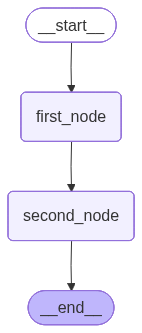

In [9]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)
graph.set_entry_point("first_node")
graph.set_finish_point("second_node")
graph.add_edge("first_node", "second_node")

app = graph.compile()
app

In [10]:
result = app.invoke({"name": "Yasaman", "age": "24"})
result

{'name': 'Yasaman', 'age': '24', 'final': 'Hi Yasaman! You are 24 years old!'}

# Exercise

In [11]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [12]:
class AgentState(TypedDict):
    name: str
    age: int
    skills: List[str]
    message: str

In [18]:
def greeter(state: AgentState) -> AgentState:
    """Adds a greeting to name."""
    state['message'] = f"Hey {state['name']}, Welcome!"
    return state

def age_txt(state: AgentState) -> AgentState:
    """Describes the user's age."""
    state['message'] += f" You are {state['age']} years old!"
    return state

def skills_txt(state: AgentState) -> AgentState:
    """Lists user's skills."""
    state['message'] += f" You have skills in " + ", ".join(state['skills'])
    return state

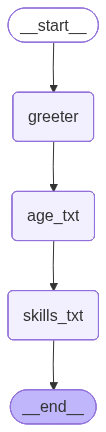

In [19]:
graph = StateGraph(state_schema=AgentState)
graph.add_node("greeter", greeter)
graph.add_node("age_txt", age_txt)
graph.add_node("skills_txt", skills_txt)
graph.set_entry_point("greeter")
graph.set_finish_point("skills_txt")
graph.add_edge("greeter", "age_txt")
graph.add_edge("age_txt", "skills_txt")

app = graph.compile()
app

In [20]:
result = app.invoke({"name": "Alice", "age": 24, "skills": ["fighting", "crazy", "weird"]})
result

{'name': 'Alice',
 'age': 24,
 'skills': ['fighting', 'crazy', 'weird'],
 'message': 'Hey Alice, Welcome! You are 24 years old! You have skills in fighting, crazy, weird'}